In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('placement.csv')

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


## Steps
1. Preprocessing + EDA + Feature Selection
2. Extract input and output cols
3. Scale the values
4. Train test split (Cross validation)
5. Train the model
6. Evaluate the model/model selection
7. Deploy the model

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [9]:
# removing the unnamed columns
df = df.iloc[:, 1:]   #[row, col]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


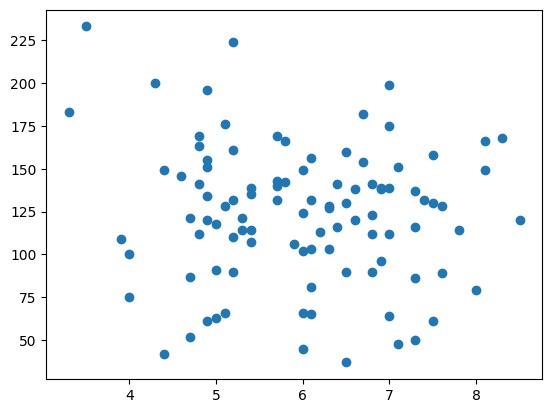

In [11]:
plt.scatter(df['cgpa'], df['iq'])

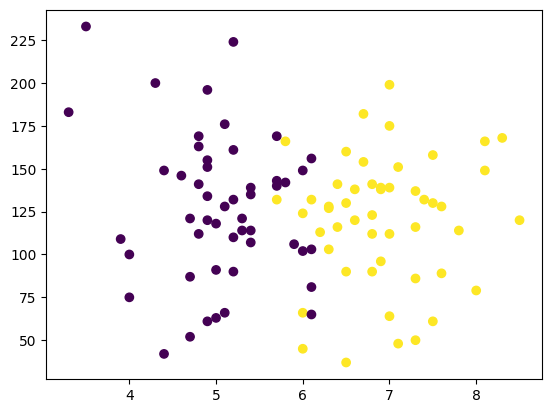

In [12]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement']) # yellow -> 1 & purple -> 0

In [13]:
# Extract input and output cols
X = df.iloc[:, 0:2]  # Storing independent input cols
Y = df.iloc[:,-1]    # Storing output col

In [18]:
 # Train test split
from sklearn.model_selection import train_test_split

## this functions gives 4 values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

In [19]:
X_train

,cgpa,iq
93,6.8,112.0
37,8.1,149.0
75,4.8,169.0
1,5.9,106.0
17,3.3,183.0
...,...,...
22,4.9,120.0
19,5.2,132.0
21,7.1,151.0
45,6.0,66.0


In [20]:
Y_train

93    1
37    1
75    0
1     0
17    0
     ..
22    0
19    0
21    1
45    1
40    0
Name: placement, Length: 90, dtype: int64

# Scaling the values

In [21]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_train = scaler.fit_transform(X_train)

In [25]:
X_train

array([[ 0.66667913, -0.28693717],
       [ 1.80872098,  0.61278107],
       [-1.09030833,  1.09911525],
       [-0.12396523, -0.43283742],
       [-2.40804893,  1.43954917],
       [ 1.105926  , -0.9191716 ],
       [-0.82676021, -1.40550578],
       [ 1.28162474,  0.83163145],
       [-0.73891084,  0.90458157],
       [ 0.40313101,  0.88026487],
       [ 0.40313101, -2.11069034],
       [-0.56321209, -0.23830375],
       [ 0.40313101,  0.1507636 ],
       [ 0.66667913, -0.01945337],
       [-0.56321209, -0.40852071],
       [-0.73891084,  2.43653424],
       [ 1.105926  , -1.79457312],
       [-1.1781577 , -0.06808679],
       [-1.79310332, -0.57873767],
       [ 0.49098039,  0.34529727],
       [-0.29966397,  0.39393069],
       [-0.73891084, -0.82190476],
       [ 0.66667913,  0.41824739],
       [ 0.05173352, -1.42982249],
       [ 0.40313101, -0.82190476],
       [ 0.75452851,  0.36961398],
       [-1.00245896,  0.75868132],
       [ 0.49098039, -0.09240349],
       [ 1.105926  ,

In [26]:
X_test = scaler.transform(X_test)

In [27]:
X_test

array([[-0.65106147, -0.23830375],
       [-1.79310332, -1.1866554 ],
       [-1.09030833,  0.41824739],
       [-0.03611585, -0.53010426],
       [ 0.31528164, -0.18967033],
       [-1.44170582,  0.61278107],
       [ 0.75452851, -0.67600451],
       [-0.56321209,  0.27234714],
       [-1.00245896,  0.66141448],
       [ 1.105926  ,  0.32098056]])

# Training the Model

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf = LogisticRegression()

In [30]:
clf.fit(X_train, Y_train)

LogisticRegression()

In [35]:
# Evaluating the Model
y_pred = clf.predict(X_test) # Predicted values

In [32]:
# Actual values
Y_test

46    0
68    0
51    0
62    0
13    1
88    0
66    1
49    0
89    0
61    1
Name: placement, dtype: int64

In [33]:
# Calculating the accuracy
from sklearn.metrics import accuracy_score

In [36]:
accuracy_score(Y_test, y_pred)

0.9

In [37]:
# deploynig part
import pickle

In [ ]:
pickle.dum(clf, open('model.pkl', 'wb'))